In [ ]:
#python -m pip install ipykernel
#DIPLOMADO: MACHINE LEARNING EN SEGUROS
#Temas: Visualización Avanzada de Datos
#Medidas Estadísticas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, norm
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import anderson
import plotly.graph_objects as go
rng = np.random.default_rng()
x = stats.uniform.rvs(size=75, random_state=rng)
sns.set(style="darkgrid")

In [3]:
#Importar base de datos
df = pd.read_csv('insurance.csv')

In [4]:
#Dimensión de la base de datos
df.shape

(1338, 7)

In [5]:
#Cabecera: Primeros renglones de la base
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#Últimos elementos de la base
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
#Tipos de escalas de medición de las variables: int64 numérica entera, object categórica y float64 numérica continua
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [8]:
#Valores faltantes en las variables: Salida lógica: True, False
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [9]:
#Conteo de valores faltantes
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
#Resumen de las variables numéricas
summary = df.describe()
print(summary)

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [11]:
#Resumen de las variables discretas
print(df.describe(include='object'))

         sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


In [12]:
#Cuartiles
np.percentile(df.age, [25, 50, 75])

array([27., 39., 51.])

In [13]:
#Forma alternativa
df['age'].quantile([0.25, 0.50, 0.75])


0.25    27.0
0.50    39.0
0.75    51.0
Name: age, dtype: float64

In [14]:
#Cuartiles de todas las variables numéricas
df[['age','bmi','children','charges']].quantile([0.25, 0.50, 0.75])

,age,bmi,children,charges
0.25,27.0,26.29625,0.0,4740.287150
0.50,39.0,30.40000,1.0,9382.033000
0.75,51.0,34.69375,2.0,16639.912515


In [15]:
#Centiles o percentiles
np.percentile(df.age, np.arange(0, 100, 10))

array([18., 19., 24., 29., 34., 39., 44., 49., 54., 59.])

In [16]:
#Sub-bases
subset = df[['age','bmi','children','charges']]
subset

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [17]:
#Deciles de las variables en la sob-base
print(subset.quantile(np.arange(0.1, 1, 0.1)))

      age      bmi  children       charges
0.1  19.0  22.9900       0.0   2346.533615
0.2  24.0  25.3260       0.0   3991.575720
0.3  29.0  27.3600       0.0   5484.846770
0.4  34.0  28.7970       0.0   7369.052730
0.5  39.0  30.4000       1.0   9382.033000
0.6  44.0  32.0320       1.0  11399.857160
0.7  49.0  33.6600       2.0  13767.875345
0.8  54.0  35.8600       2.0  20260.626406
0.9  59.0  38.6195       3.0  34831.719700


In [18]:
#Centiles en esa sub-base
print(subset.quantile(np.arange(0.01, 1, 0.01)))

       age       bmi  children       charges
0.01  18.0  17.89515       0.0   1252.972730
0.02  18.0  19.27140       0.0   1621.741650
0.03  18.0  19.96045       0.0   1636.154889
0.04  18.0  20.52000       0.0   1709.934254
0.05  18.0  21.25600       0.0   1757.753400
...    ...       ...       ...           ...
0.95  62.0  41.10600       3.0  41181.827787
0.96  62.0  41.80000       3.0  42915.605644
0.97  63.0  42.45340       4.0  44492.862728
0.98  63.0  43.91860       4.0  46676.189821
0.99  64.0  46.40790       5.0  48537.480726

[99 rows x 4 columns]


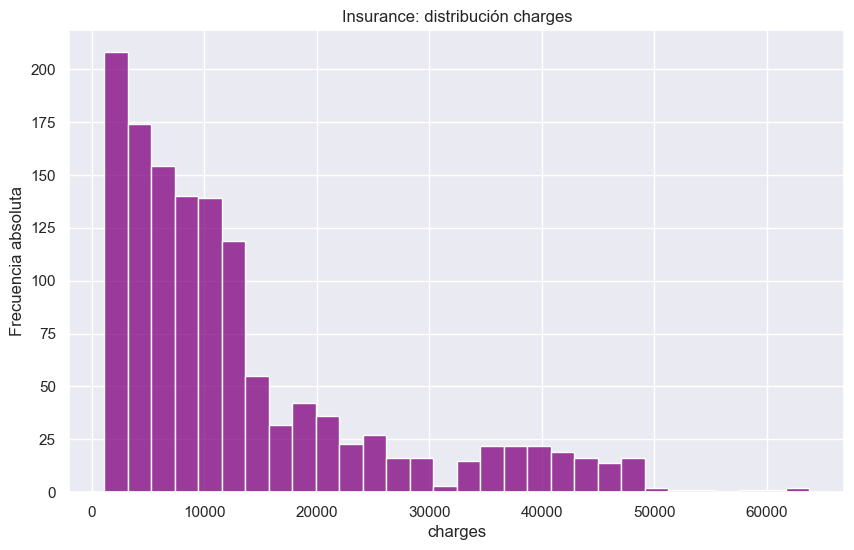

In [19]:
#Descripción gráfica: Histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='charges', color='purple')
plt.title('Insurance: distribución charges')
plt.xlabel('charges')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()


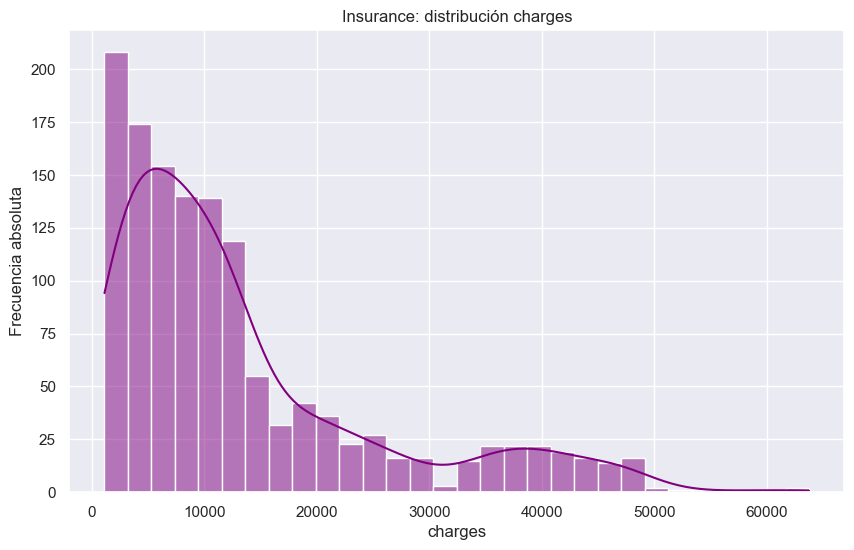

In [ ]:
#Anexando una densidad suavizada (tipo kernel)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='charges', color='purple', kde=True) # kde añade la densidad tipo kernel(subyacente a los datos)
plt.title('Insurance: distribución charges')
plt.xlabel('charges')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [ ]:
#Violinplot
sns.violinplot(data=df, y="charges")

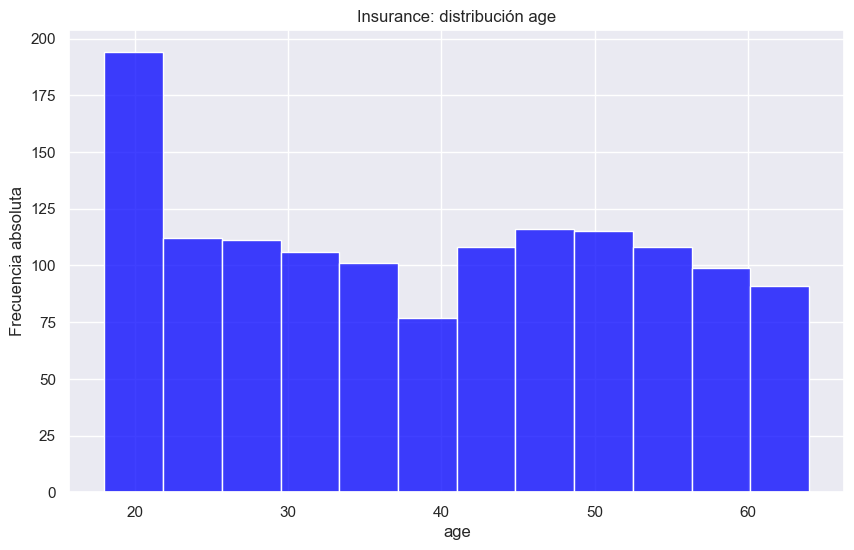

In [21]:
#Histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', color='blue') #bins controla el número de particiones
plt.title('Insurance: distribución age')
plt.xlabel('age')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [22]:
#Transformación logarítmica de la variable charges
df['logcharges'] = np.log(df['charges'])

<Axes: xlabel='logcharges', ylabel='Density'>

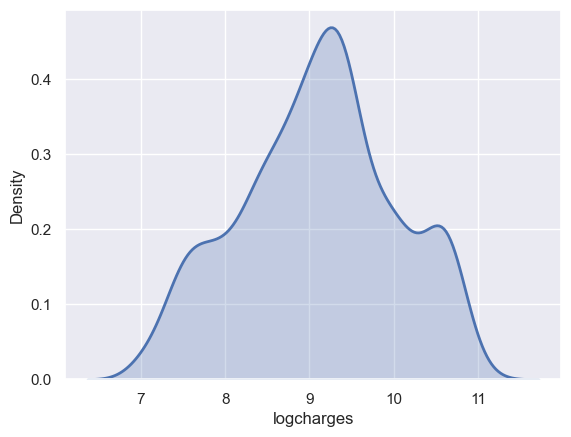

In [23]:
#Densidas suavizada 
sns.kdeplot(x=df['logcharges'], fill=True, linewidth=2)

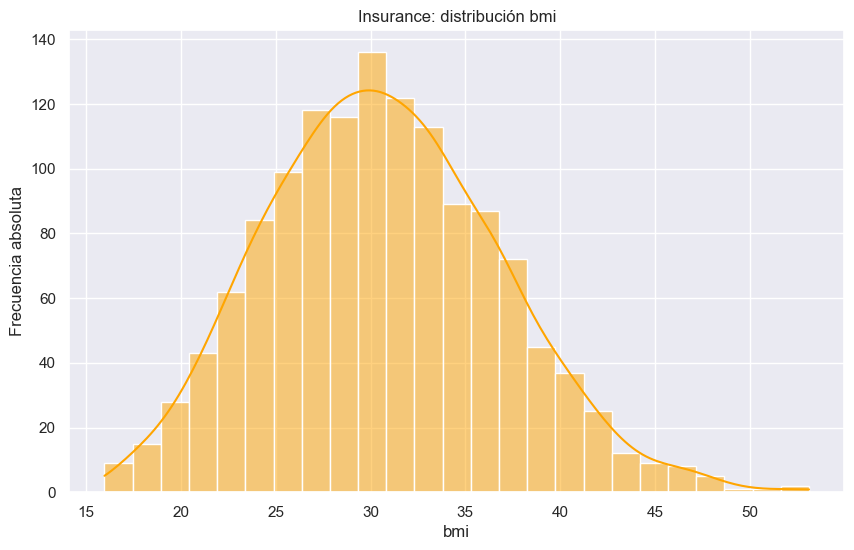

In [24]:
#Densidad del ídice de masa corporal (bmi)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='bmi', color='orange', kde=True)
plt.title('Insurance: distribución bmi')
plt.xlabel('bmi')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [25]:
#El histograma sugiere que la variable podría ser normal

sesgo = df.bmi.skew()
curtosis = df.bmi.kurtosis()

print(f"Sesgo: {sesgo:.4f}")
print(f"Curtosis: {curtosis:.4f}")


Sesgo: 0.2840
Curtosis: -0.0507


In [26]:
#El histograma y densidad anterior, sugieren que bmi pudiera tener distribución normal. Comprobemos si es así
#Kolmogorov-Smirnoff test (gof)
bmi_gof = stats.goodness_of_fit(stats.norm, df.bmi, statistic='ks', rng=rng)
bmi_gof.statistic, bmi_gof.pvalue

(np.float64(0.026099881197044872), np.float64(0.0301))

In [27]:
#Pueba de Anderson-Darling de bondad de ajuste (gof)
ad_result = stats.goodness_of_fit(stats.norm, df.bmi, statistic='ad', rng=rng)
print('Statistic: %.3f' % ad_result.statistic)
print('Statistic: %.3f' % ad_result.pvalue)

Statistic: 1.236
Statistic: 0.004


In [ ]:
#Shapiro-Wilk test( gof) 
statistic, p_value = stats.shapiro(df.bmi)# no se define distribucion porque solo sirve para probar normalidad
print(f"Test Statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")

Test Statistic: 0.9939
p-value: 0.0000


In [29]:
#La variable children está declarada como numérica. Para hacer una gráfica de barras, que tiene más sentido de
#acuerdo a sus pocos valores, la transformamos a categórica
df['children_cat'] = pd.Categorical(df['children'])

<Figure size 1000x600 with 0 Axes>

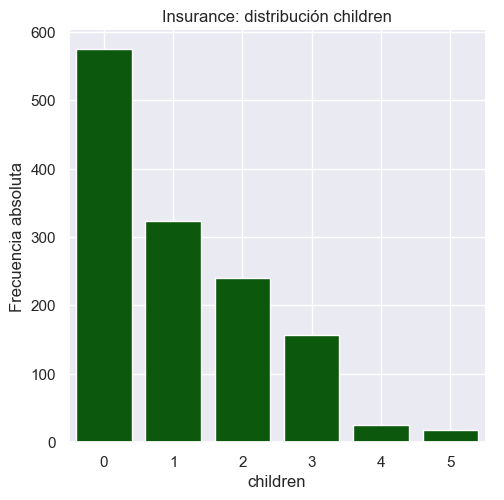

In [30]:
#Su gráfica de barras
plt.figure(figsize=(10, 6))
sns.catplot(data=df, x='children_cat', kind="count",color='darkgreen')
plt.title('Insurance: distribución children')
plt.xlabel('children')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [ ]:
#Gráfica de barras para sex
plt.figure(figsize=(10, 6))
sns.catplot(data=df, x='sex', kind="count",color='darkred')
plt.title('Insurance: distribución sex')
plt.xlabel('sex')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [ ]:
#Gráfica de smoker
plt.figure(figsize=(10, 6))
sns.catplot(data=df, x='smoker', kind="count",color='darkmagenta')
plt.title('Insurance: distribución smoker')
plt.xlabel('smoker')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [ ]:
#Con valores encima de las barras
sns.set(rc={'figure.figsize':(15,8)})
ax=sns.countplot(x='smoker',data=df,color='magenta')
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.38, patch_height+10))
plt.show()


In [ ]:
#Región
plt.figure(figsize=(10, 6))
sns.catplot(data=df, x='region', kind="count",color='darkviolet')
plt.title('Insurance: distribución region')
plt.xlabel('region')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [ ]:
#Más simple
sns.countplot(data=df, x="region")
plt.title('Insurance: distribución region')

In [ ]:
#Comparación de poblaciones a través de box-plot: charges por sexo
sns.boxplot(data=df, x="charges", hue="sex")


In [ ]:
#Comparación de poblaciones a través de densidades: charges por sexo
sns.kdeplot(data=df, x="charges", hue="sex", fill=True)
plt.title('Charges: Comparación por sexo')
plt.show()

In [ ]:
#Comparación estadística. Es claro que difícilmente esas dos poblaciones son normales, entonces, para compararlas
#usaremos la prueba no paramétrica U de Mann-Witney
filtered_male = df[(df['sex'] == 'male')&(df['charges'])] #charges para hombres
filtered_female = df[(df['sex'] == 'female')&(df['charges'])] #charges para mujeres

stat, p_value = mannwhitneyu(filtered_female.charges,filtered_male.charges,alternative='two-sided')
print("U Statistic:", stat)
print("P-value:", p_value)



In [ ]:
#Índice de masa corporal (bmi): Comparación por sexo a través de box-plot
sns.boxplot(data=df, x="bmi", hue="sex")

In [ ]:
#Índice de masa corporal: Comparación por sexo a través de densidades
sns.kdeplot(data=df, x="bmi", hue="sex", fill=True)
plt.title('BMI: Comparación por sexo')
plt.show()

In [ ]:
#Comparación formal: Probaremos que las dos poblaciones son normales de varianzas iguales y utilizaremos un t-student
#Pruebas de normalidad
bmi_male = df[(df['sex'] == 'male')&(df['bmi'])]
bmi_female = df[(df['sex'] == 'female')&(df['bmi'])]
bmi_male_gof = stats.goodness_of_fit(stats.norm, bmi_male.bmi, statistic='ks', rng=rng)
bmi_female_gof = stats.goodness_of_fit(stats.norm, bmi_female.bmi, statistic='ks', rng=rng)

print(bmi_male_gof.statistic), print(bmi_male_gof.pvalue)
print(bmi_female_gof.statistic), print(bmi_female_gof.pvalue)


In [ ]:
#Prueba de homogeneidad de varianzas (igualdad de varianzas)

levene_stat, levene_p = stats.levene(bmi_male.bmi, bmi_female.bmi)

bartlett_stat, bartlett_p = stats.bartlett(bmi_male.bmi, bmi_female.bmi)

print("Levene test:", levene_stat)
print("Levene_p-value:", levene_p)

print("Bartlett test:", bartlett_stat)
print("Bartlett_p-value:", bartlett_p)


In [ ]:
#T-student
t_stat, p_value = stats.ttest_ind(bmi_male.bmi, bmi_female.bmi, equal_var=True)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


In [ ]:
#Comparación de poblaciones a través de densidades: charges por smoker
plt.figure(figsize=(15, 8))
sns.kdeplot(data=df, x="charges", hue="smoker", fill=True, palette='Set2')
plt.title('Charges: Comparación por condición de fumar')
plt.show()


In [ ]:
#Comparación de estas poblaciones. Es claro que no son poblaciones normales, entonces, para compararlas
#usaremos la prueba no paramétrica U de Mann-Witney
filtered_smoker = df[(df['smoker'] == 'yes')&(df['charges'])] #charges para fumadores
filtered_nosmoker = df[(df['smoker'] == 'no')&(df['charges'])] #charges para no fumadores

stat, p_value = mannwhitneyu(filtered_smoker.charges,filtered_nosmoker.charges,alternative='two-sided')
print("U Statistic:", stat)
print("P-value:", p_value)

In [ ]:
#Comparación gráfica entre variables categóricas: smoker por sex

sns.countplot(data=df, x="sex", hue="smoker")
plt.title('Insurance: Comparación sex y smoker')
plt.xlabel('sex')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()


In [ ]:
#Habrá asoción estadísticamente significativa entre estas variables categóricas

contingency_table = pd.crosstab(df['sex'], df['smoker'])

print("Contingency Table:")
print(contingency_table)


In [ ]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, 
                   index=contingency_table.index, 
                   columns=contingency_table.columns))
#Decisión
alpha = 0.05
if p < alpha:
    print("\nDecisión: Rechazar la hipótesis nula — Hay una asociación estadísticamente significativa entre estas variables.")
else:
    print("\nDecisión: No rechazar la hipótesis nula — No hay asociación significativa entre las variables.")


In [ ]:
#Scatter plot
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x="charges", y="bmi")
plt.title('Insurance: Scatter plot charges bmi')
plt.xlabel('charges')
plt.ylabel('bmi')
plt.grid(True)
plt.show()

In [ ]:
#SEparando por condición de fumar
plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=df,
    x="charges",
    y="bmi",
    hue="smoker" )
plt.show()

In [ ]:
#Correlación
sns.regplot(data=df, x="charges", y="bmi")
plt.title('Insurance: Scatter plot charges bmi')
plt.xlabel('charges')
plt.ylabel('bmi')
plt.grid(True)
plt.show()

In [ ]:
sns.regplot(data=df, x="charges", y="bmi", lowess=True)
plt.title('Insurance: Scatter plot charges bmi')
plt.xlabel('charges')
plt.ylabel('bmi')
plt.grid(True)
plt.show()


In [ ]:
#Pearson
r, p_value = pearsonr(df.charges,df.bmi)
print("Coeficiente de correlación de Pearson:", round(r,4))
print("p-value:", p_value)


In [ ]:
#Spearman rho
rho, p = spearmanr(df.charges,df.bmi)
print("Coeficiente de correlación de Spearman:", round(rho,4))
print("p-value:", p)

In [ ]:
#tau de Kendall
tau, p = kendalltau(df.charges,df.bmi)
print("Coeficiente de correlación de Kendall:", round(tau,4))
print("p-value:", p)

In [ ]:
#Misma relación con seaborn
plt.figure(figsize=(15, 8))
sns.lmplot(x="charges", y="bmi", hue="smoker", data=df)
plt.show()

In [ ]:
#Comparaciones multivariadas
#pairplot. Si no se le indica nada, la función selecciona del data.frame las variables numéricas
#Nosotros guardamos la variable logcharges y children_cat en ella, así que hay que quitarlas
df.head()


In [ ]:
dropped_df = df.drop(columns=['logcharges', 'children_cat'])
dropped_df.head()

In [ ]:
#Si no se le indica otra cosa, esta función grafica las variables numéricas por pares
sns.pairplot(dropped_df)

In [ ]:
#Segmentadas por sex
sns.pairplot(dropped_df, hue="sex")
plt.show()

In [ ]:
sns.pairplot(dropped_df, hue="sex", diag_kind="hist")

In [ ]:
sns.pairplot(dropped_df, kind="kde")

In [ ]:
#Matriz de correlación 
df_corr=df[['age','bmi','children','charges']]
df_matrix=df_corr.corr()
print(df_matrix)

In [ ]:
#Heatmap
plt.figure(figsize=(13, 7))
sns.heatmap(df_matrix, annot=True , cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones: Heatmap')
plt.show()

In [ ]:
###Correlaciones policóricas

In [ ]:
pip install ordinalcorr

In [ ]:
from ordinalcorr import hetcor

In [ ]:
#Matriz de correlaciones policórica
data = pd.DataFrame({
     "charges": df.charges,
     "age": df.age,
    "bmi": df.bmi,
     "children": df.children,
     "smoker": df.smoker,
     "sex": df.sex,
     "region": df.region,
 })
hc_df=hetcor(data)
print(hc_df)

In [ ]:
plt.figure(figsize=(13, 7))
sns.heatmap(hc_df, annot=True , cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones policóricas: Heatmap')
plt.show()

In [ ]:
df_spearman_matrix=df_corr.corr(method='spearman')
print(df_spearman_matrix)

In [ ]:
plt.figure(figsize=(13, 7))
sns.heatmap(df_spearman_matrix, annot=True , cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones de Spearman: Heatmap')
plt.show()

In [ ]:
df_kendall_matrix=df_corr.corr(method='kendall')
print(df_kendall_matrix)

In [ ]:
plt.figure(figsize=(13, 7))
sns.heatmap(df_kendall_matrix, annot=True , cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones de Kendall: Heatmap')
plt.show()

In [ ]:
#Facet
plt.figure(figsize=(18, 10))
g1 = sns.FacetGrid(df, col="smoker",  row="sex")
g1.map(sns.scatterplot, "charges","bmi")

In [ ]:
plt.figure(figsize=(18, 10))
g2 = sns.FacetGrid(df, col="smoker",  row="sex")
g2.map_dataframe(sns.histplot, x="charges")

In [ ]:
plt.figure(figsize=(18, 10))
g3 = sns.FacetGrid(df, col="smoker", hue="sex")
g3.map_dataframe(sns.scatterplot, x="charges", y="bmi")
g3.add_legend()

In [ ]:
g4 = sns.FacetGrid(df, col="region", height=3.5, aspect=.65)
g4.map(sns.histplot, "charges")